/Users/juliomorales/Library/CloudStorage/GoogleDrive-juliomorales1823@gmail.com/My Drive/Graduate School/Research/Projects/Helioseismology/Vesa_2025/Code/diagnostic_diagram/functions.py:320: RuntimeWarning: divide by zero encountered in reciprocal
  v_phase = omega*kz**(-1) # km/s
/Users/juliomorales/Library/CloudStorage/GoogleDrive-juliomorales1823@gmail.com/My Drive/Graduate School/Research/Projects/Helioseismology/Vesa_2025/Code/diagnostic_diagram/functions.py:320: RuntimeWarning: invalid value encountered in multiply
  v_phase = omega*kz**(-1) # km/s


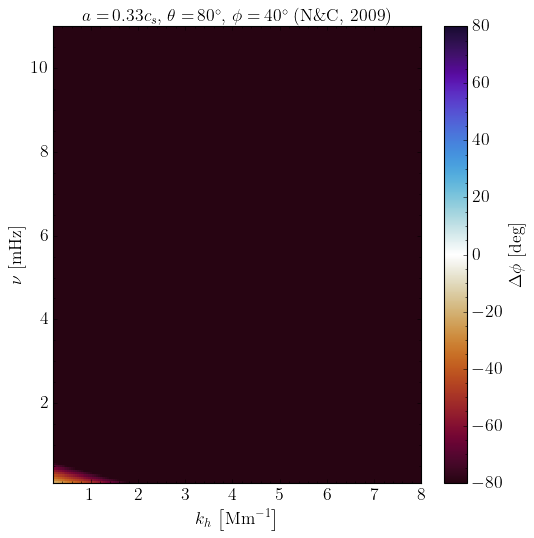

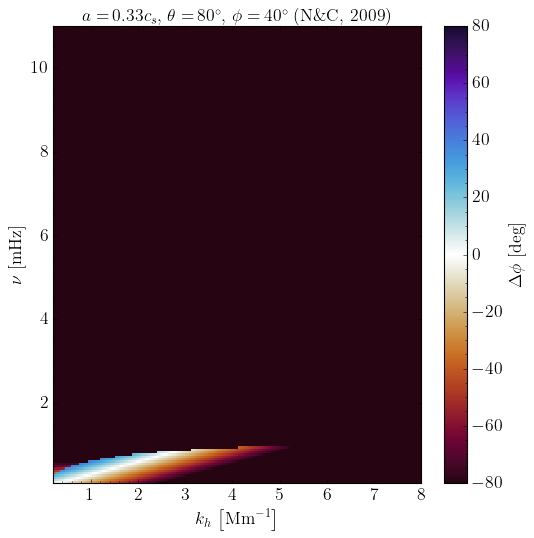

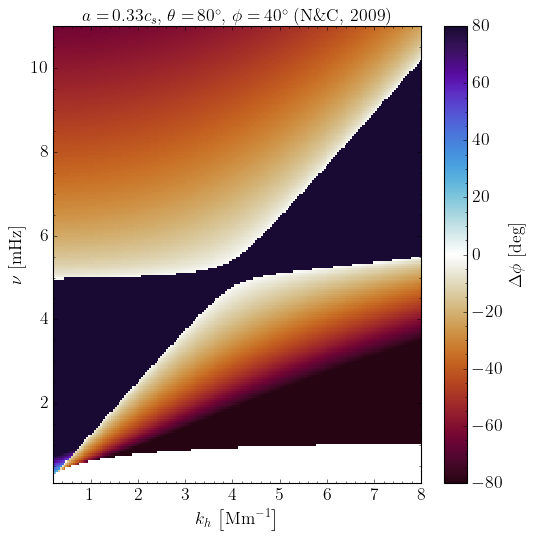

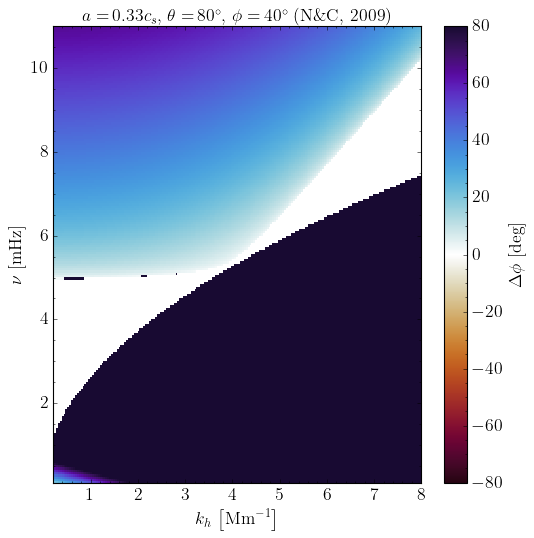

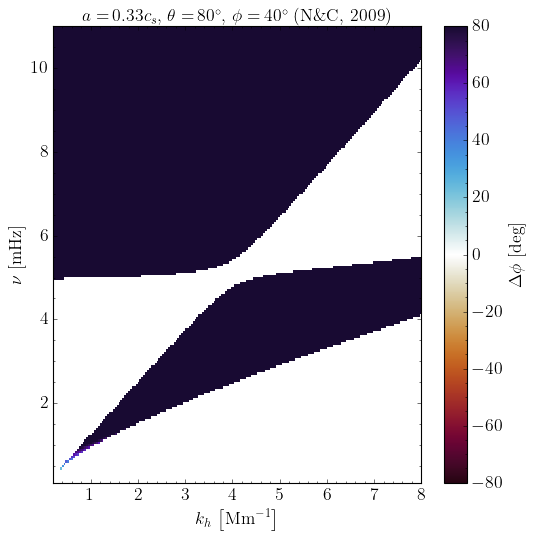

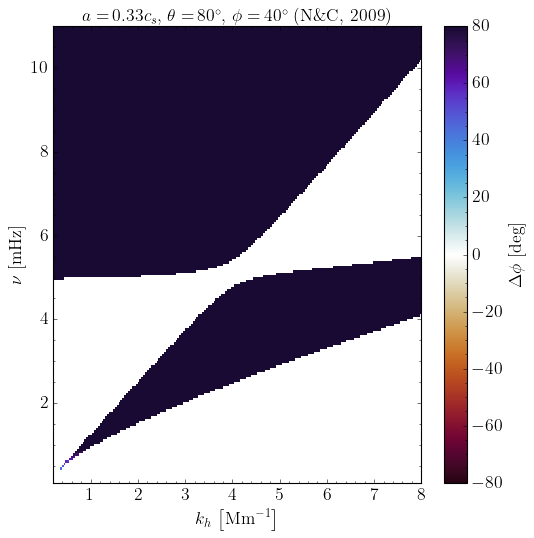

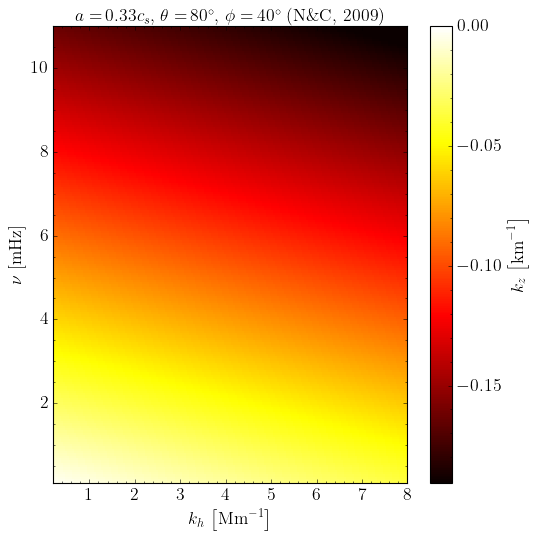

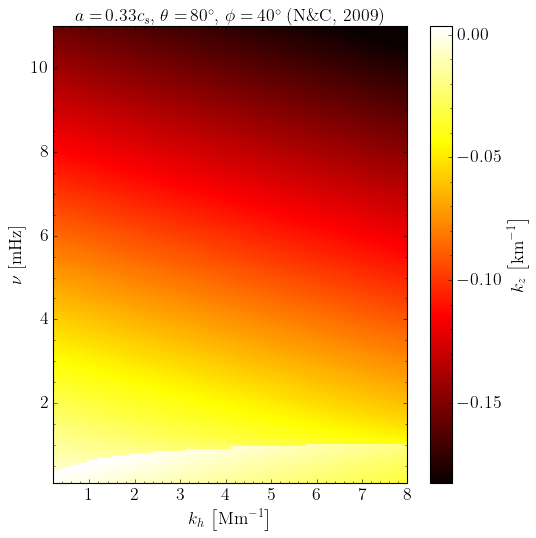

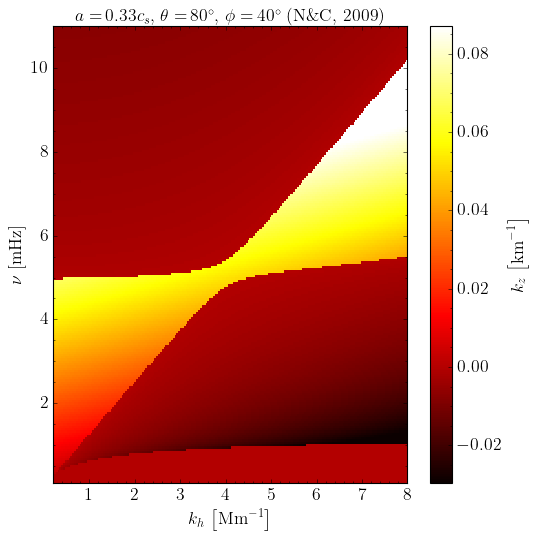

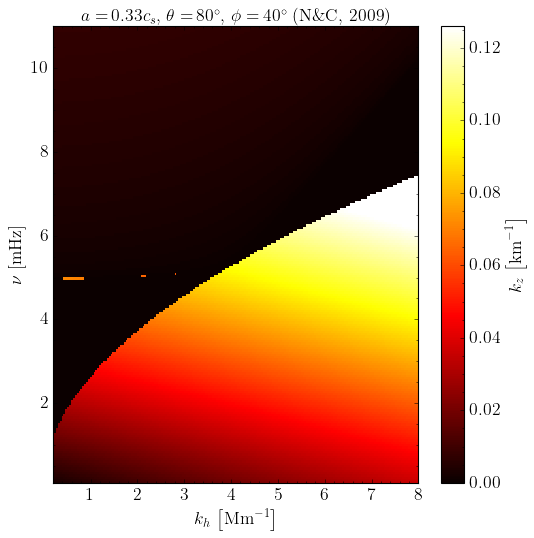

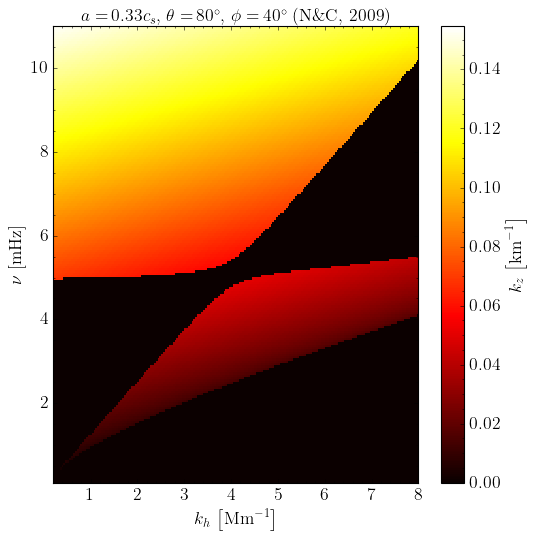

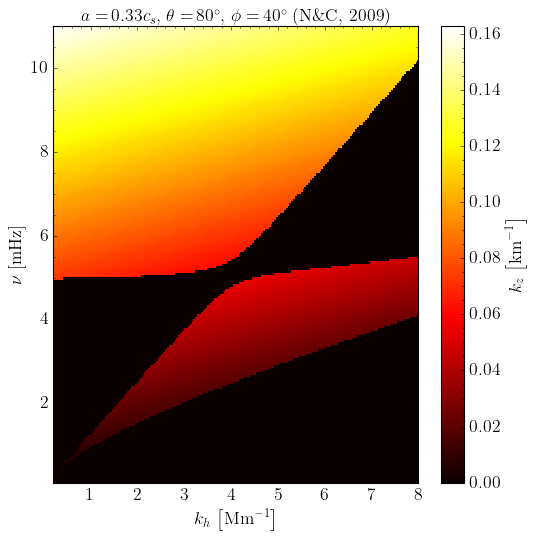

In [ ]:
# Import relevant libraries
import config as dd_config
import functions as dd_funcs
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib
import cmasher as cmr
from math import pi
from joblib import Parallel, delayed
from astropy.visualization import ZScaleInterval
from astropy.io import fits
from matplotlib import rc

# Create figure features
cmap_name = cmr.fusion
frequency_label = r'$\nu\,\left[\mathrm{mHz}\right]$'
wavenumber_label  = r'$k_{h}\,\left[\mathrm{Mm}^{-1}\right]$'
colorbar_label_kz = r'$k_{z}\,\left[\mathrm{km}^{-1}\right]$'
colorbar_label_phase = r'$\Delta\phi\,\left[\mathrm{deg}\right]$'

tex_fonts = {   "text.usetex": True,
                "font.family": "serif",
                 "font.serif": "Times New Roman",
             "axes.labelsize": 16,
                  "font.size": 16,
            "legend.fontsize": 14,
            "xtick.labelsize": 16,
            "ytick.labelsize": 16,
             "axes.titlesize": 16,
            "xtick.direction": "in",
            "ytick.direction": "in",
             "legend.frameon": True,
          "legend.framealpha": 0.8,
"axes.formatter.use_mathtext": True,
            "lines.linewidth": 2,
        "ytick.minor.visible": True,
        "xtick.minor.visible": True,
                "savefig.dpi": 300,
             "pcolor.shading": "auto",
           "figure.facecolor": "white"}

# Update matplotlib settings
plt.style.use("classic")
matplotlib.rcParams.update(tex_fonts)
rc("mathtext", **{"default": "regular"})

# Define grids
kh = np.linspace(0, 8, 200)*1e-3  # km^-1
omega = np.linspace(0, 11, 200)*2*pi*1e-3 # rad/s
kh_grid, omega_grid = np.meshgrid(kh, omega)  # km^-1, rad/s

# Intialize the diagnostic diagram
params = dd_config.params
model  = 'nc2009'
diagram_class = dd_funcs.DiagnosticDiagram(kh_grid, omega_grid, params[model])

# Conversion factors
rad_to_mHz = (2*pi)**(-1)*1e3  # rad/s to mHz
inv_km_to_Mm = 1e3  # km^-1 to Mm^-1

# Calculate the bounds where kz^2 < 0 and calculate kz
nu = np.array(Parallel(n_jobs = -1, backend = 'loky')(delayed(diagram_class.omega_solve)(i) for i in kh))*rad_to_mHz
kz = np.stack(Parallel(n_jobs = -1, backend = 'loky')(delayed(diagram_class.kz_solve)(i) for i in kh), axis = 1)

# Calculate grids and f-mode dispersion for plotting
kh_plot  = kh_grid*inv_km_to_Mm # Mm^-1
nu_plot  = omega_grid*rad_to_mHz  # mHz
fmode_nu = diagram_class.fmode_dispersion()*rad_to_mHz

# Subtract mode contamination
if (model == 'nc2009'):
    evan_indices = np.nonzero((nu_plot >= (nu[:, 1])) & (nu_plot <= (nu[:, 2])))
    kz[:, :, 3][evan_indices] = 0.0

# # Color the AGWs red
# agw_indices = np.nonzero(nu_plot < fmode_nu)
# kz[:, :, 3][agw_indices]  = -kz[:, :, 0][agw_indices]

# Calculate the corresponding phase speed and phase difference using list comprehensions per kz-mode
v_phase = [diagram_class.phase_speed(omega_grid, kz[:, :, n]) for n in range(params[model]['kz_order'])]  # km/s
delta_phi = [diagram_class.phase_difference(omega_grid, v_phase[n], dd_config.dz) for n in range(params[model]['kz_order'])]  # rad

# Plot the diagnostic diagram
interval = ZScaleInterval()

# Plot the phase differences
for i in range(0, params[model]['kz_order']):
    phase_difference = np.nan_to_num(delta_phi[i]*180*pi**(-1), nan = 0.0, posinf=0.0, neginf=0.0) # degrees
    if np.all(np.isclose(phase_difference, 0.0, rtol=1e-09, atol=1e-09)):
        plt.close()
        continue
    # Make the plot
    plt.figure(figsize=(7, 7))
    # plt.plot(kh_plot[0], fmode_nu, 'gray')
    # if (model == 'nc2009') or (model == 'bunte1993'):
    #     plt.plot(kh_plot[0], kh*(dd_config.ax*rad_to_mHz), color='black', linestyle='-')
    vmin, vmax = -80, 80
    plt.pcolormesh(kh_plot, nu_plot, phase_difference, cmap=cmr.fusion, shading="auto", norm=mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax), rasterized=True)
    plt.colorbar(label=colorbar_label_phase)
    # for j in range(0, params[model]['omega_order']):
    #     plt.plot(kh_plot[0], nu[:, j], 'k-', markersize=3)
    plt.title(f'Diagnostic Diagram for {diagram_class.model.upper()}')
    plt.xlabel(wavenumber_label)
    plt.ylabel(frequency_label)
    plt.xlim(0.2, np.max(kh_plot))
    plt.ylim(0.1, np.max(nu_plot))
    plt.tight_layout()
    plt.title(params[model]['title'])
    plt.show()
    #break  # Remove this line to plot all modes

for i in range(0, params[model]['kz_order']):
    kz_i = kz[:, :, i]
    if np.all(np.isclose(kz_i, 0.0, rtol=1e-09, atol=1e-09)):
        plt.close()
        continue
    # Plot the kz_grids
    plt.figure(figsize=(7, 7))
    # plt.plot(kh_plot[0], fmode_nu, 'gray')
    # if (model == 'nc2009') or (model == 'bunte1993'):
    #     plt.plot(kh_plot[0], kh*dd_config.ax*rad_to_mHz, color='green', linestyle='-')
    vmin, vmax = interval.get_limits(kz_i)
    plt.pcolormesh(kh_plot, nu_plot, kz_i, cmap='hot', shading="auto", vmin=vmin, vmax=vmax, rasterized=True)
    plt.colorbar(label=colorbar_label_kz)
    # for j in range(0, params[model]['omega_order']):
    #     plt.plot(kh_plot[0], nu[:, j], 'k*', markersize=3)
    plt.title(f'Diagnostic Diagram for {diagram_class.model.upper()}')
    plt.xlabel(wavenumber_label)
    plt.ylabel(frequency_label)
    plt.xlim(0.2, np.max(kh_plot))
    plt.ylim(0.1, np.max(nu_plot))
    plt.tight_layout()
    plt.title(params[model]['title'])
    plt.show()
    # break  # Remove this line to plot all kz modes

/Users/juliomorales/Library/CloudStorage/GoogleDrive-juliomorales1823@gmail.com/My Drive/Graduate School/Research/Projects/Helioseismology/Vesa_2025/Code/diagnostic_diagram/functions.py:320: RuntimeWarning: divide by zero encountered in reciprocal
  v_phase = omega*kz**(-1) # km/s
/Users/juliomorales/Library/CloudStorage/GoogleDrive-juliomorales1823@gmail.com/My Drive/Graduate School/Research/Projects/Helioseismology/Vesa_2025/Code/diagnostic_diagram/functions.py:320: RuntimeWarning: invalid value encountered in multiply
  v_phase = omega*kz**(-1) # km/s


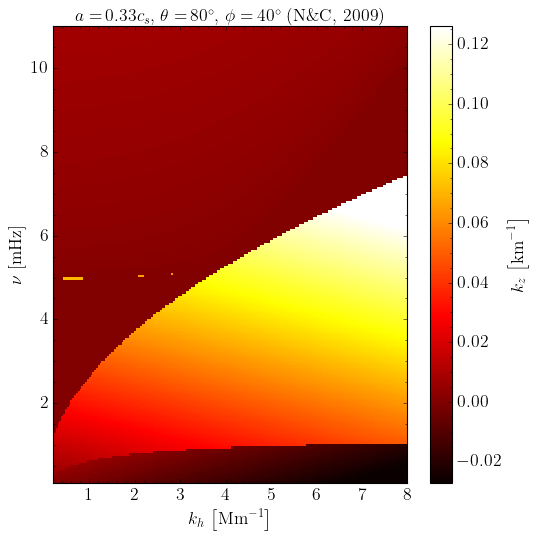

In [2]:
L = 15
y_test = L*np.sqrt(5*kh)
indices = np.nonzero(kz[:, :, 2] == 0.0)
kz[:, :, 3][indices] = kz[:, :, 1][indices]
kz_test = kz[:, :, 3]
v_phase_test = diagram_class.phase_speed(omega_grid, kz_test)  # km/s
delta_phi_test = diagram_class.phase_difference(omega_grid, v_phase_test, dd_config.dz)  # rad
phase_difference_test = np.nan_to_num(delta_phi_test*180*pi**(-1), nan = 0.0, posinf=0.0, neginf=0.0) # degrees

plt.figure(figsize=(7, 7))
# plt.plot(kh_plot[0], fmode_nu, 'gray')
# if (model == 'nc2009') or (model == 'bunte1993'):
#     plt.plot(kh_plot[0], kh*dd_config.ax*rad_to_mHz, color='green', linestyle='-')
vmin, vmax = interval.get_limits(kz_test)
plt.pcolormesh(kh_plot, nu_plot, kz_test, cmap='hot', shading="auto", vmin=vmin, vmax=vmax, rasterized=True)
plt.colorbar(label=colorbar_label_kz)
# Plot the indices with red circles
# plt.scatter(kh_plot[0][indices[1]], nu_plot[:,0][indices[0]], color='green', s=1, label='Indices below y_test')
# Plot the non-zero indices with blue circles
# for j in range(0, params[model]['omega_order']):
#     plt.plot(kh_plot[0], nu[:, j], 'k*', markersize=3)
# plt.plot(kh_plot[0], nu[:, 1], 'k*', markersize=3)
plt.title(f'Diagnostic Diagram for {diagram_class.model.upper()}')
plt.xlabel(wavenumber_label)
plt.ylabel(frequency_label)
plt.xlim(0.2, np.max(kh_plot))
plt.ylim(0.1, np.max(nu_plot))
plt.tight_layout()
plt.title(params[model]['title'])
plt.show()

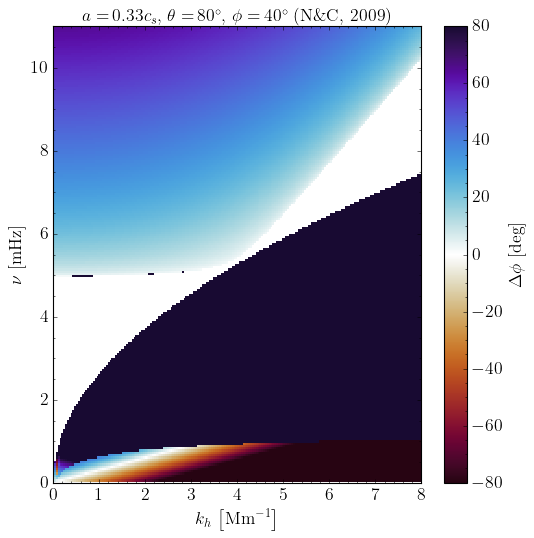

In [3]:

plt.figure(figsize=(7, 7))
# plt.plot(kh_plot[0], fmode_nu, 'gray')
# if (model == 'nc2009') or (model == 'bunte1993'):
#     plt.plot(kh_plot[0], kh*(dd_config.ax*rad_to_mHz), color='black', linestyle='-')
vmin, vmax = -80, 80
plt.pcolormesh(kh_plot, nu_plot, phase_difference_test, cmap=cmr.fusion, shading="auto", norm=mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax), rasterized=True)
# Plot the prob_indices
plt.colorbar(label=colorbar_label_phase)
# for j in range(0, params[model]['omega_order']):
#     plt.plot(kh_plot[0], nu[:, j], 'k-', markersize=3)
plt.title(f'Diagnostic Diagram for {diagram_class.model.upper()}')
plt.xlabel(wavenumber_label)
plt.ylabel(frequency_label)
plt.xlim(0.0, np.max(kh_plot))
plt.ylim(0.0, np.max(nu_plot))
plt.tight_layout()
plt.title(params[model]['title'])
plt.show()